In [18]:
# Cell 1 - Settings & imports
TARGET = 'whole milk'   # <-- change this to predict another item present in dataset
USE_CLASS_WEIGHT = False  # If True, use class_weight='balanced' for LogisticRegression
USE_OVERSAMPLING = False  # If True, apply RandomOverSampler on training set (imblearn required)

DATA_PATH = '/content/Groceries data (1).csv'

# Standard imports
import os
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7,5)


In [19]:
# Cell 2 - Load and inspect data

df = pd.read_csv("Groceries data (1).csv")
print("Data shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())


Data shape: (38765, 7)
Columns: ['Member_number', 'Date', 'itemDescription', 'year', 'month', 'day', 'day_of_week']


,Member_number,Date,itemDescription,year,month,day,day_of_week
0,1808,2015-07-21,tropical fruit,2015,7,21,1
1,2552,2015-05-01,whole milk,2015,5,1,4
2,2300,2015-09-19,pip fruit,2015,9,19,5
3,1187,2015-12-12,other vegetables,2015,12,12,5
4,3037,2015-01-02,whole milk,2015,1,2,4


In [20]:
# Cell 3 - Build transactions (baskets)
# By default: group by Member_number + Date to form a single basket per visit.
# If you have an invoice ID column, replace the grouping key accordingly.

df['InvoiceID'] = df['Member_number'].astype(str) + '_' + df['Date'].astype(str)
grouped = df.groupby('InvoiceID')['itemDescription'].apply(list).reset_index(name='items')

# Quick peek
print("Number of transactions:", len(grouped))
print("Example basket (first):", grouped.loc[0,'items'][:20])


Number of transactions: 14963
Example basket (first): ['whole milk', 'pastry', 'salty snack']


In [21]:
# Cell 4 - Binarize items (one-hot per item)
mlb = MultiLabelBinarizer(sparse_output=False)
X_full = pd.DataFrame(mlb.fit_transform(grouped['items']), columns=mlb.classes_, index=grouped.index)
print("Distinct items:", X_full.shape[1])
print("Sample columns (first 40):", list(X_full.columns)[:40])
mlb


Distinct items: 167
Sample columns (first 40): ['Instant food products', 'UHT-milk', 'abrasive cleaner', 'artif. sweetener', 'baby cosmetics', 'bags', 'baking powder', 'bathroom cleaner', 'beef', 'berries', 'beverages', 'bottled beer', 'bottled water', 'brandy', 'brown bread', 'butter', 'butter milk', 'cake bar', 'candles', 'candy', 'canned beer', 'canned fish', 'canned fruit', 'canned vegetables', 'cat food', 'cereals', 'chewing gum', 'chicken', 'chocolate', 'chocolate marshmallow', 'citrus fruit', 'cleaner', 'cling film/bags', 'cocoa drinks', 'coffee', 'condensed milk', 'cooking chocolate', 'cookware', 'cream', 'cream cheese ']


MultiLabelBinarizer()

In [22]:
# Cell 5 - Create target vector and features
if TARGET not in X_full.columns:
    raise ValueError(f"TARGET '{TARGET}' not found among items. Available example items: {list(X_full.columns)[:30]}")

y = X_full[TARGET].astype(int)
X = X_full.drop(columns=[TARGET])

print("Target distribution (counts):")
print(y.value_counts())
pos_frac = y.mean()
print(f"Positive fraction: {pos_frac:.4f}")


Target distribution (counts):
whole milk
0    12600
1     2363
Name: count, dtype: int64
Positive fraction: 0.1579


In [38]:
# Cell 6 - Train-test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4,random_state=42, stratify=y)
print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])
print("Train positive fraction:", y_train.mean(), "Test positive fraction:", y_test.mean())


Train size: 8977 Test size: 5986
Train positive fraction: 0.15795922914113847 Test positive fraction: 0.15786835950551287


In [24]:
# Cell 7 - (Optional) Handle class imbalance with oversampling
if USE_OVERSAMPLING:
    try:
        from imblearn.over_sampling import RandomOverSampler
    except Exception as e:
        raise RuntimeError("imblearn not installed. Install with `pip install imbalanced-learn` to use oversampling.") from e
    ros = RandomOverSampler(random_state=42)
    X_train_os, y_train_os = ros.fit_resample(X_train, y_train)
    print("After oversampling, train shape:", X_train_os.shape, "Pos frac:", y_train_os.mean())
else:
    X_train_os, y_train_os = X_train, y_train


In [35]:
# Cell 8 - Initialize models
nb = BernoulliNB()
if USE_CLASS_WEIGHT:
    lr = LogisticRegression(solver='liblinear', max_iter=2000, class_weight='balanced')
else:
    lr = LogisticRegression(solver='liblinear', max_iter=2000)




In [36]:
# Fit
nb.fit(X_train_os, y_train_os)


BernoulliNB()

In [37]:
# Fit
lr.fit(X_train_os, y_train_os)

LogisticRegression(max_iter=2000, solver='liblinear')

In [26]:
# Cell 9 - Predictions and probabilities
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:,1]

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]


In [33]:
# Cell 10A - Evaluation: BernoulliNB
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def print_eval(y_true, y_pred, y_prob, model_name):
    print(f"\n===== {model_name} =====")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    # ROC AUC (if both classes present)
    try:
        auc = roc_auc_score(y_true, y_prob)
        print("ROC AUC:", round(auc, 4))
    except ValueError:
        print("ROC AUC: could not compute (single class in y_true).")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm)




In [34]:
# --- Evaluate BernoulliNB ---
print_eval(y_test, y_pred_nb, y_prob_nb, "BernoulliNB")


===== BernoulliNB =====
Accuracy: 0.8413
ROC AUC: 0.6299

Classification report:
              precision    recall  f1-score   support

           0     0.8421    0.9988    0.9138      5041
           1     0.1429    0.0011    0.0021       945

    accuracy                         0.8413      5986
   macro avg     0.4925    0.4999    0.4579      5986
weighted avg     0.7317    0.8413    0.7699      5986

Confusion matrix (rows=true, cols=pred):
[[5035    6]
 [ 944    1]]


In [32]:
print_eval(y_test, y_pred_lr, y_prob_lr, "LogisticRegression")



===== LogisticRegression =====
Accuracy: 0.8426
ROC AUC: 0.707

Classification report:
              precision    recall  f1-score   support

           0     0.8428    0.9996    0.9145      5041
           1     0.7143    0.0053    0.0105       945

    accuracy                         0.8426      5986
   macro avg     0.7785    0.5024    0.4625      5986
weighted avg     0.8225    0.8426    0.7718      5986

Confusion matrix (rows=true, cols=pred):
[[5039    2]
 [ 940    5]]


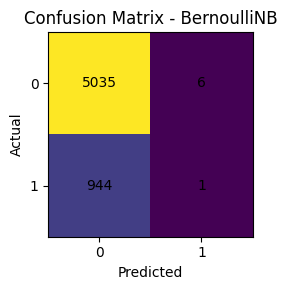

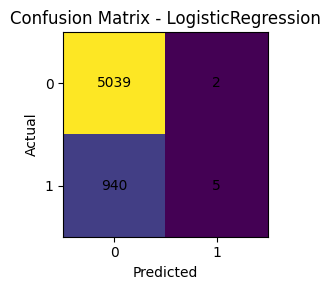

In [14]:
# Cell 11 - Plot confusion matrix (image)
def plot_confusion_matrix(cm, title="Confusion matrix"):
    plt.figure(figsize=(4,3))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    ticks = [0,1]
    plt.xticks(ticks)
    plt.yticks(ticks)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j], ha='center', va='center')
    plt.tight_layout()
    plt.show()

cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_lr = confusion_matrix(y_test, y_pred_lr)

plot_confusion_matrix(cm_nb, title="Confusion Matrix - BernoulliNB")
plot_confusion_matrix(cm_lr, title="Confusion Matrix - LogisticRegression")


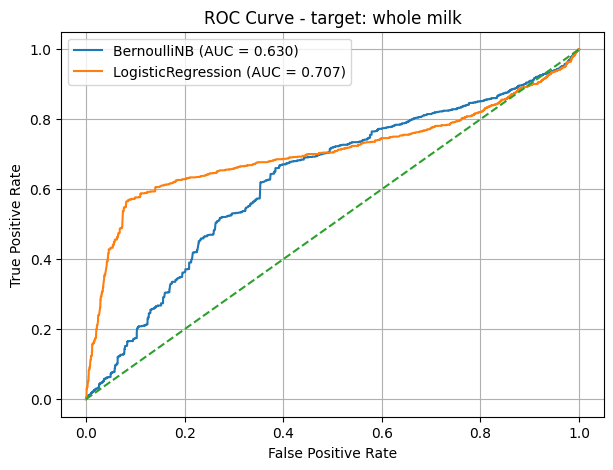

In [15]:
# Cell 12 - ROC curves (NB vs LR)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_nb = roc_auc_score(y_test, y_prob_nb)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure()
plt.plot(fpr_nb, tpr_nb, label=f'BernoulliNB (AUC = {auc_nb:.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'LogisticRegression (AUC = {auc_lr:.3f})')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - target: {TARGET}')
plt.legend()
plt.grid(True)
plt.show()


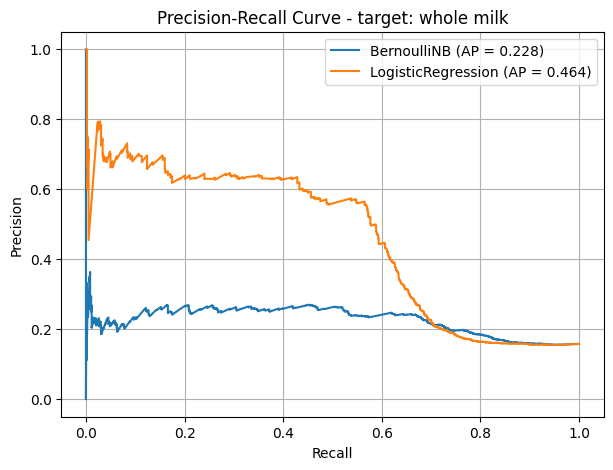

In [16]:
# Cell 13 - Precision-Recall curves (good for imbalanced data)
precision_nb, recall_nb, _ = precision_recall_curve(y_test, y_prob_nb)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
ap_nb = average_precision_score(y_test, y_prob_nb)
ap_lr = average_precision_score(y_test, y_prob_lr)

plt.figure()
plt.plot(recall_nb, precision_nb, label=f'BernoulliNB (AP = {ap_nb:.3f})')
plt.plot(recall_lr, precision_lr, label=f'LogisticRegression (AP = {ap_lr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - target: {TARGET}')
plt.legend()
plt.grid(True)
plt.show()


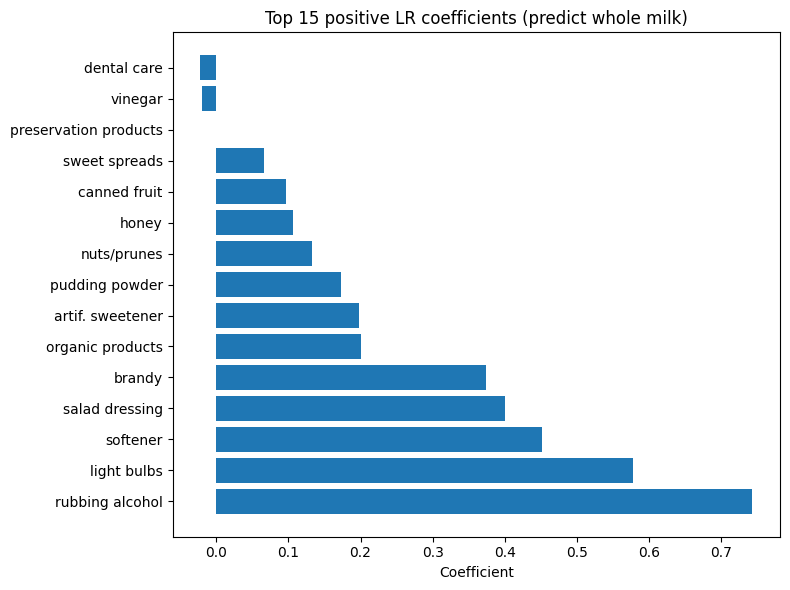

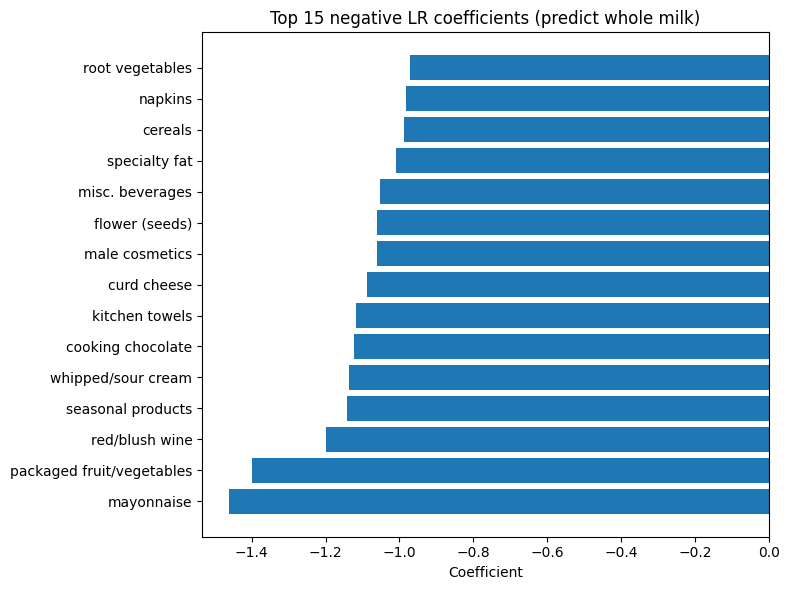

In [17]:
# Cell 14 - (Optional) Top logistic regression coefficients
# Show top positive and negative features (items) that influence predicting the TARGET.
n_top = 15
if hasattr(lr, "coef_"):
    coefs = lr.coef_.ravel()
    feat_names = X.columns.to_numpy()
    coef_df = pd.DataFrame({'feature': feat_names, 'coef': coefs})
    coef_df = coef_df.sort_values('coef', ascending=False)
    top_pos = coef_df.head(n_top)
    top_neg = coef_df.tail(n_top).iloc[::-1]  # reverse for plotting

    plt.figure(figsize=(8,6))
    plt.barh(top_pos['feature'], top_pos['coef'])
    plt.title(f"Top {n_top} positive LR coefficients (predict {TARGET})")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,6))
    plt.barh(top_neg['feature'], top_neg['coef'])
    plt.title(f"Top {n_top} negative LR coefficients (predict {TARGET})")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()
else:
    print("Logistic regression coefficients not available.")
